In [1]:
import numpy as np
import scipy.fft as fft
import matplotlib.pyplot as plt

Image shape: (90, 90)


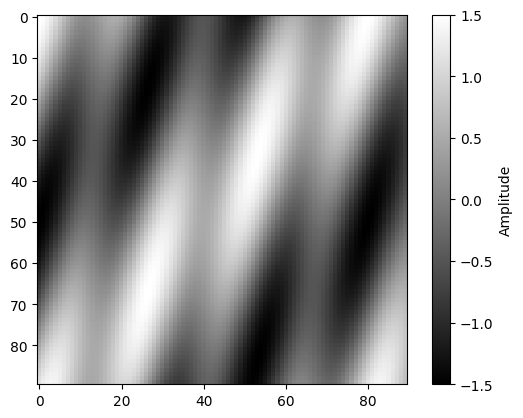

In [16]:
# Generate a sample "continuous" signal
# Two constant frequencies
f1 = 15 # Hz
f2 = 60 # Hz

# and amplitudes
a1 = 1
a2 = 0.5

# Time interval
T = 1 / (f2 * 20)

# period is the greatest common denominator of the two frequencies
P = 1 / np.gcd(int(f1), int(f2))

# Number of samples
N = int(P / T) + 10

# this time, define spatial coordinates
t = np.arange(N) * T

img = np.zeros((N, N))
for row in range(N):
    # shift = 0
    shift = row * 2 * np.pi / (N + 10)
    img[row,:] = a1 * np.cos(f1 * 2*np.pi*t + shift) + a2 *np.cos(f2 * 2*np.pi*t + shift)

# display as an image
# plt.plot(img[0,:])
plt.imshow(img, cmap="grey")
plt.colorbar(label="Amplitude")
print(f"Image shape: {img.shape}")

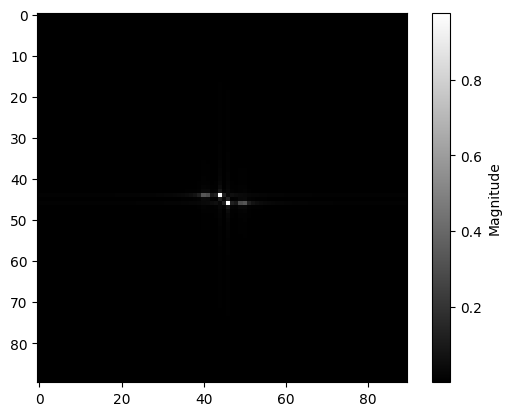

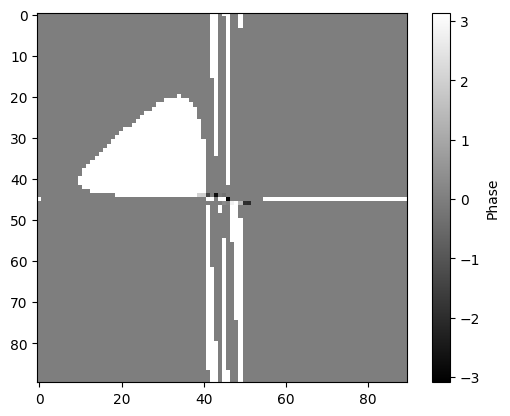

In [17]:
# 2D fft!
F = fft.fftshift(fft.fft2(img)) * 2 / N**2
plt.imshow(abs(F), cmap="grey")
plt.colorbar(label="Magnitude")

plt.figure()
phase_mask = abs(F) > 0.1
plt.imshow(np.angle(F*phase_mask), cmap="grey")
plt.colorbar(label="Phase")

## Loading images with [Pillow](https://pillow.readthedocs.io/en/stable/index.html)
A popular library for image processing, forked from the now-defunct PIL (python image library). Used under the hood by PyTorch, Scikit-Image, Matplotlib, and almost every other Python library that works with images (except for openCV).

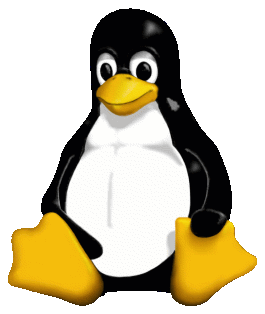

In [18]:
from PIL import Image
tux = Image.open("Tux.png")
tux

In [22]:
# Tux here has an indexed colour pallette
print(tux.getbands()) # channels
palette = tux.getpalette()
print(f"Tux is drawn with {len(palette) // 3} colours. The first few are:")

for c in range(5):
    print(palette[c*3:c*3+3])



('P',)
Tux is drawn with 194 colours. The first few are:
[255, 255, 255]
[131, 82, 4]
[210, 168, 81]
[230, 179, 63]
[91, 58, 5]


In [23]:
rgb_tux = tux.convert("RGB") # from palette to RGB
np_tux = np.asarray(rgb_tux) / 255 # rescale as float with max 1
print(np_tux.shape)
print(np_tux[0,0,:])

(314, 265, 3)
[1. 1. 1.]


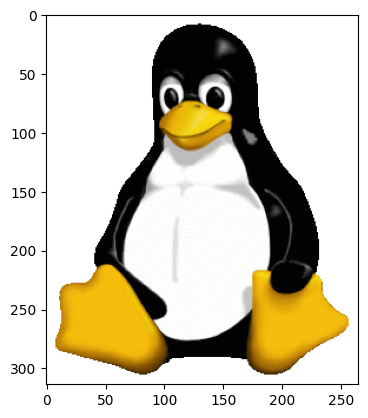

In [24]:
plt.imshow(np_tux)

In [25]:
# write the new RGB image to disk, still as PNG
rgb_tux.save("rgb_tux.png")

In [28]:
%ls -lh *.png

 Volume in drive C is Windows
 Volume Serial Number is 3CC2-B558

 Directory of c:\Users\ccurtis\Documents\data3464\w26\demo_code\11_images


 Directory of c:\Users\ccurtis\Documents\data3464\w26\demo_code\11_images

03/24/2026  09:21 AM            28,577 rgb_tux.png
03/24/2026  08:27 AM            11,913 Tux.png
               2 File(s)         40,490 bytes
               0 Dir(s)  138,554,556,416 bytes free


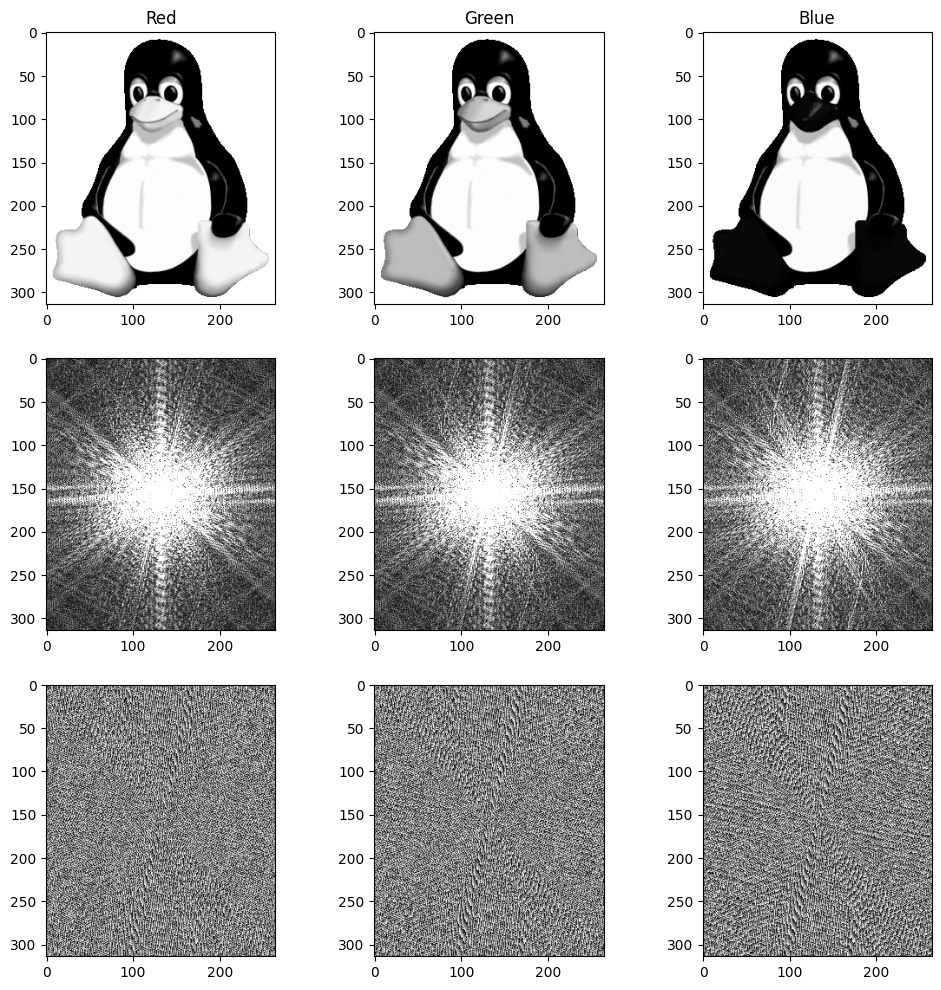

In [31]:
# What does the fourier transform of Tux look like?
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
channel_names = ["Red", "Green", "Blue"]
for i in range(3):
     # Huge DC component, so clamp it
     axes[0,i].imshow(np_tux[:,:,i], cmap="grey")
     axes[0,i].set_title(channel_names[i])
     F_channel = fft.fftshift(fft.fft2(np_tux[:,:,i]))
     # Magnitude
     axes[1,i].imshow(abs(F_channel), vmax=30, cmap="grey")
     # Phase
     axes[2,i].imshow(np.angle(F_channel), cmap="grey")

## Manipulating frequencies

In [ ]:
# Get a more realistic image
# From https://github.com/scikit-learn/scikit-learn/tree/78b2428198d0078d587e84ef89e7c273eff091cb/sklearn/datasets/images
flower = Image.open("flower.jpg")

# Convert to floating point and normalize
flower_np = np.asarray(flower) / 255

# Plot all the channels
fig, ax = plt.subplots(2, 2, figsize=(10,8))
print(flower_np.shape)
ax[0, 0].imshow(flower_np)
ax[0, 0].set_xlabel("Full colour")
ax[0, 1].imshow(flower_np[:,:,0], cmap='Greys_r')
ax[0, 1].set_xlabel("Red Channel")
ax[1, 0].imshow(flower_np[:,:,1], cmap='Greys_r')
ax[1, 0].set_xlabel("Green Channel")
ax[1, 1].imshow(flower_np[:,:,2], cmap='Greys_r')
ax[1, 1].set_xlabel("Blue Channel")

In [ ]:
# While we're at it, save a copy in in png and see the file size
flower.save("flower.png")
%ls -lh flower.*

In [ ]:
# Take the average of the colour channels to create a greyscale image
# Note: This can be weighted differently per channel! E.g. Y = 0.2125 R + 0.7154 G + 0.0721 B from https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_rgb_to_gray.html
flower_g = np.mean(flower_np, axis=2)
plt.imshow(flower_g, cmap='Greys_r')

In [ ]:
# Frequency domain version
flower_f = np.fft.fft2(flower_g)
flower_f_shifted = np.fft.fftshift(flower_f)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].set_title("Magnitude")
mag_img = ax[0].imshow(np.abs(flower_f_shifted), cmap="grey", vmax=100)
ax[1].set_title("Phase")
phase_img = ax[1].imshow(np.angle(flower_f_shifted), cmap="grey")
phase_img.set_clim(-np.pi / 2, np.pi / 2)

In [ ]:
# Create a low-pass filter
max_freq = 50
rows, cols = flower_f.shape
cr, cc = rows // 2, cols // 2

# zeros, except 1s at the centre
low_pass_filter = np.zeros_like(flower_f)
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
cdist = (Y - cr)**2 + (X - cc)**2
low_pass_filter[cdist < (max_freq / 2)**2] = 1

# multiply in frequency domain
low_f_flower = flower_f_shifted * low_pass_filter
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].set_title("Filtered Magnitude")
ax[0].imshow(np.abs(low_f_flower), cmap="grey", vmax=100)

ax[1].set_title("Filtered Phase")
ax[1].imshow(np.angle(low_f_flower), cmap="grey")
plt.show()

In [ ]:
# Inverse FFT of the filtered image
plt.imshow(np.real(np.fft.ifft2(np.fft.ifftshift(low_f_flower))), cmap="grey")


In [ ]:
# High frequency version
high_f_flower = flower_f_shifted * (1 - low_pass_filter)
plt.imshow(np.real(np.fft.ifft2(np.fft.ifftshift(high_f_flower))), cmap="grey")
